In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Crop_and_fertilizer_with_usage.csv")
df.head()

,District_Name,Soil_color,Nitrogen,Phosphorus,Potassium,pH,Rainfall,Temperature,Crop,Fertilizer,Link,Fertilizer_Usage
0,Kolhapur,Black,75,50,100,6.5,1000,20,Sugarcane,Urea,https://youtu.be/2t5Am0xLTOo,68.86
1,Kolhapur,Black,80,50,100,6.5,1000,20,Sugarcane,Urea,https://youtu.be/2t5Am0xLTOo,88.52
2,Kolhapur,Black,85,50,100,6.5,1000,20,Sugarcane,Urea,https://youtu.be/2t5Am0xLTOo,84.69
3,Kolhapur,Black,90,50,100,6.5,1000,20,Sugarcane,Urea,https://youtu.be/2t5Am0xLTOo,83.16
4,Kolhapur,Black,95,50,100,6.5,1000,20,Sugarcane,Urea,https://youtu.be/2t5Am0xLTOo,71.15


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4513 entries, 0 to 4512
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   District_Name     4513 non-null   object 
 1   Soil_color        4513 non-null   object 
 2   Nitrogen          4513 non-null   int64  
 3   Phosphorus        4513 non-null   int64  
 4   Potassium         4513 non-null   int64  
 5   pH                4513 non-null   float64
 6   Rainfall          4513 non-null   int64  
 7   Temperature       4513 non-null   int64  
 8   Crop              4513 non-null   object 
 9   Fertilizer        4513 non-null   object 
 10  Link              4513 non-null   object 
 11  Fertilizer_Usage  4513 non-null   float64
dtypes: float64(2), int64(5), object(5)
memory usage: 423.2+ KB


In [4]:
df.describe()

,Nitrogen,Phosphorus,Potassium,pH,Rainfall,Temperature,Fertilizer_Usage
count,4513.000000,4513.000000,4513.000000,4513.000000,4513.000000,4513.000000,4513.000000
mean,95.409927,54.341901,63.595170,6.715267,819.189010,25.915134,76.587407
std,38.060648,16.551991,35.691911,0.625198,251.730813,5.897328,29.228860
min,20.000000,10.000000,5.000000,5.500000,300.000000,10.000000,13.440000
25%,60.000000,40.000000,40.000000,6.000000,600.000000,20.000000,53.780000
50%,105.000000,55.000000,55.000000,6.500000,800.000000,25.000000,78.470000
75%,125.000000,65.000000,75.000000,7.000000,1000.000000,30.000000,98.020000
max,150.000000,90.000000,150.000000,8.500000,1700.000000,40.000000,150.970000


In [5]:
print(df["Soil_color"].unique())
print(df["Crop"].unique())
print(df["Fertilizer"].unique())

['Black' 'Red ' 'Medium Brown' 'Dark Brown' 'Red' 'Light Brown'
 'Reddish Brown']
['Sugarcane' 'Jowar' 'Cotton' 'Rice' 'Wheat' 'Groundnut' 'Maize' 'Tur'
 'Urad' 'Moong' 'Gram' 'Masoor' 'Soybean' 'Ginger' 'Turmeric' 'Grapes']
['Urea' 'DAP' 'MOP' '10:26:26 NPK' 'SSP' 'Magnesium Sulphate'
 '13:32:26 NPK' '12:32:16 NPK' '50:26:26 NPK' '19:19:19 NPK'
 'Chilated Micronutrient' '18:46:00 NPK' 'Sulphur' '20:20:20 NPK'
 'Ammonium Sulphate' 'Ferrous Sulphate' 'White Potash' '10:10:10 NPK'
 'Hydrated Lime']


Missing Values:
District_Name       0
Soil_color          0
Nitrogen            0
Phosphorus          0
Potassium           0
pH                  0
Rainfall            0
Temperature         0
Crop                0
Fertilizer          0
Link                0
Fertilizer_Usage    0
dtype: int64


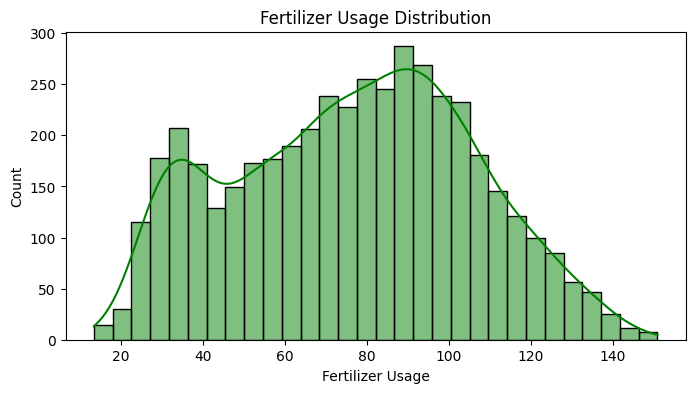

In [6]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

# Fertilizer Usage Distribution
plt.figure(figsize=(8,4))
sns.histplot(df['Fertilizer_Usage'],
             bins=30,
             kde=True,
             color='green')
plt.title('Fertilizer Usage Distribution')
plt.xlabel('Fertilizer Usage')
plt.ylabel('Count')
plt.show()

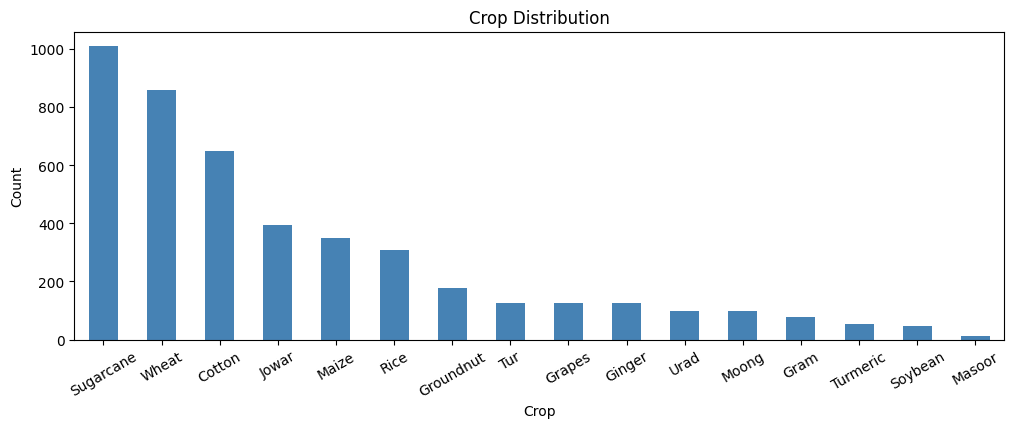

In [7]:
# Crop distribution
plt.figure(figsize=(12,4))
df['Crop'].value_counts().plot(
    kind='bar',
    color='steelblue')
plt.title('Crop Distribution')
plt.xlabel('Crop')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.show()

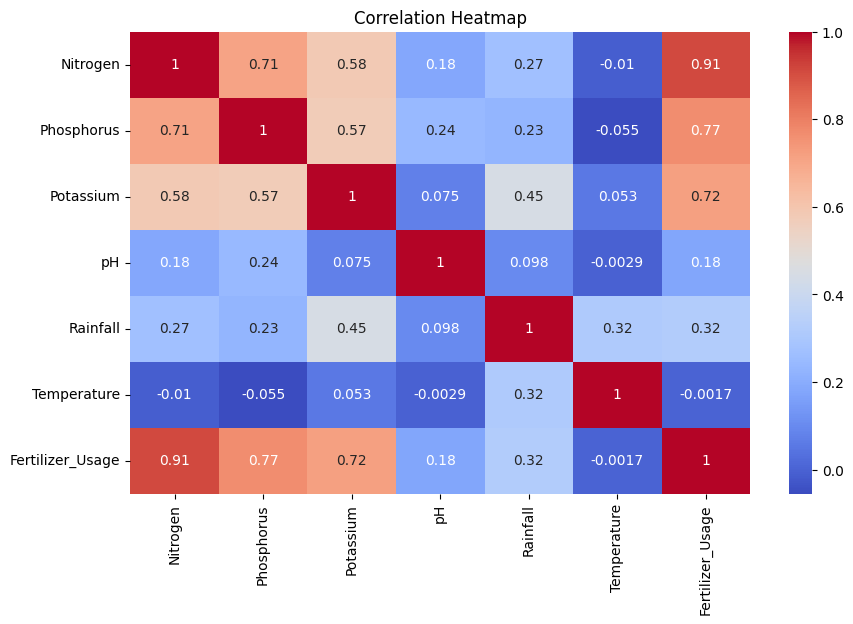

In [8]:
# Correlation heatmap
plt.figure(figsize=(10,6))
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [9]:
df.drop(columns=["Link"], inplace=True)
df.head()

,District_Name,Soil_color,Nitrogen,Phosphorus,Potassium,pH,Rainfall,Temperature,Crop,Fertilizer,Fertilizer_Usage
0,Kolhapur,Black,75,50,100,6.5,1000,20,Sugarcane,Urea,68.86
1,Kolhapur,Black,80,50,100,6.5,1000,20,Sugarcane,Urea,88.52
2,Kolhapur,Black,85,50,100,6.5,1000,20,Sugarcane,Urea,84.69
3,Kolhapur,Black,90,50,100,6.5,1000,20,Sugarcane,Urea,83.16
4,Kolhapur,Black,95,50,100,6.5,1000,20,Sugarcane,Urea,71.15


In [10]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for i in ["District_Name","Soil_color",
          "Crop","Fertilizer"]:
    df[i] = le.fit_transform(df[i])

df.head()

,District_Name,Soil_color,Nitrogen,Phosphorus,Potassium,pH,Rainfall,Temperature,Crop,Fertilizer,Fertilizer_Usage
0,0,0,75,50,100,6.5,1000,20,11,17,68.86
1,0,0,80,50,100,6.5,1000,20,11,17,88.52
2,0,0,85,50,100,6.5,1000,20,11,17,84.69
3,0,0,90,50,100,6.5,1000,20,11,17,83.16
4,0,0,95,50,100,6.5,1000,20,11,17,71.15


In [11]:
from sklearn.model_selection import train_test_split

x = df.drop(columns=["Fertilizer_Usage"])
y = df["Fertilizer_Usage"]

xtrain, xtest, ytrain, ytest = train_test_split(
    x, y, test_size=0.2, random_state=42)

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
xtrain = scaler.fit_transform(xtrain)
xtest = scaler.transform(xtest)

In [13]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(xtrain, ytrain)
ypred = model.predict(xtest)

In [14]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(ytest, ypred)
mse = mean_squared_error(ytest, ypred)
r2  = r2_score(ytest, ypred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error :", mse)
print("R-squared Score    :", r2)

Mean Absolute Error: 7.7889297858777615
Mean Squared Error : 90.78530598546523
R-squared Score    : 0.8896645000566501


In [15]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(xtrain, ytrain)
rf_pred = rf.predict(xtest)

rf_r2  = r2_score(ytest, rf_pred)
rf_mae = mean_absolute_error(ytest, rf_pred)

print("Random Forest R2 Score:", rf_r2)
print("Random Forest MAE     :", rf_mae)

Random Forest R2 Score: 0.8691741037434705
Random Forest MAE     : 8.247187264673311


Model Comparison:
Linear Regression R2: 0.8896645000566501
Random Forest R2    : 0.8691741037434705


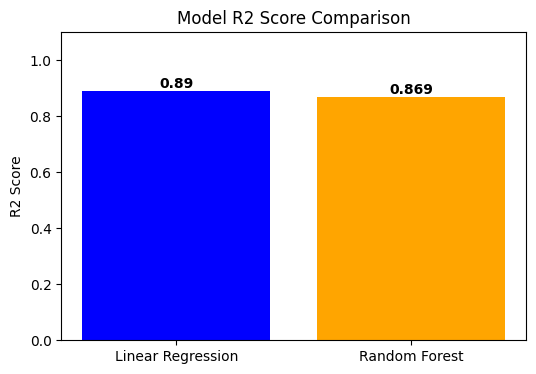

In [16]:
# Compare Linear Regression vs Random Forest
print("Model Comparison:")
print("=" * 40)
print("Linear Regression R2:", r2)
print("Random Forest R2    :", rf_r2)

# Simple bar chart
plt.figure(figsize=(6,4))
plt.bar(['Linear Regression','Random Forest'],
        [r2, rf_r2],
        color=['blue','orange'])
plt.title('Model R2 Score Comparison')
plt.ylabel('R2 Score')
plt.ylim(0, 1.1)
for i, v in enumerate([r2, rf_r2]):
    plt.text(i, v + 0.01,
             str(round(v, 3)),
             ha='center',
             fontweight='bold')
plt.show()

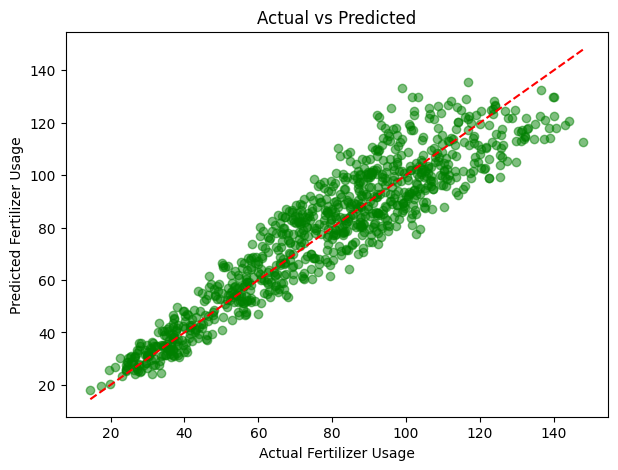

In [17]:
# Actual vs Predicted plot
plt.figure(figsize=(7,5))
plt.scatter(ytest, rf_pred,
            alpha=0.5,
            color='green')
plt.plot([ytest.min(), ytest.max()],
         [ytest.min(), ytest.max()],
         'r--')
plt.xlabel('Actual Fertilizer Usage')
plt.ylabel('Predicted Fertilizer Usage')
plt.title('Actual vs Predicted')
plt.show()